# Retail Sales Dataset — Exploratory Data Analysis

**Objective:** Uncover patterns, customer behaviour trends, and actionable business insights from retail transaction data.

**Dataset:** `retail_sales_dataset.csv` — 1,000 transactions covering the period Jan 2023 – Jan 2024, with fields for transaction date, customer demographics, product category, quantity, price, and total amount spent.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

df = pd.read_csv('retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### 1.1 Initial Inspection: Shape, Dtypes, Nulls

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Column dtypes:")
print(df.dtypes)
print("\nNull value counts:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Shape: 1000 rows x 9 columns

Column dtypes:
Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Null value counts:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0

Date range: 2023-01-01 to 2024-01-01


**Observation:** The dataset contains 1,000 transactions across 9 columns with **no missing values and no duplicate rows** — the data is clean and requires no imputation. It spans exactly one year (Jan 1, 2023 – Jan 1, 2024), covering three product categories: Beauty, Clothing, and Electronics. `Date` was converted from string to datetime for time-series analysis.

## 2. Descriptive Statistics

In [3]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

desc_stats = df[numerical_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
desc_stats['mode'] = df[numerical_cols].mode().iloc[0]
desc_stats = desc_stats[['mean', 'median', 'mode', 'std', 'min', 'max']]
desc_stats.round(2)

,mean,median,mode,std,min,max
Age,41.39,42.0,43.0,13.68,18.0,64.0
Quantity,2.51,3.0,4.0,1.13,1.0,4.0
Price per Unit,179.89,50.0,50.0,189.68,25.0,500.0
Total Amount,456.00,135.0,50.0,560.00,25.0,2000.0


**Observation:**
- **Age** averages ~41 years (median 42), fairly evenly spread between 18–64 — a broad adult customer base rather than one dominated by a single generation.
- **Quantity** per transaction is low (mean ~2.5 units, mode likely 1–4), suggesting most purchases are small, individual buys rather than bulk orders.
- **Total Amount** has a mean of $456 but a much higher standard deviation (~$560), and the median is well below the mean — indicating a **right-skewed distribution** driven by a subset of high-value transactions (likely Electronics/Clothing at higher price points).

## 3. Time Series Analysis

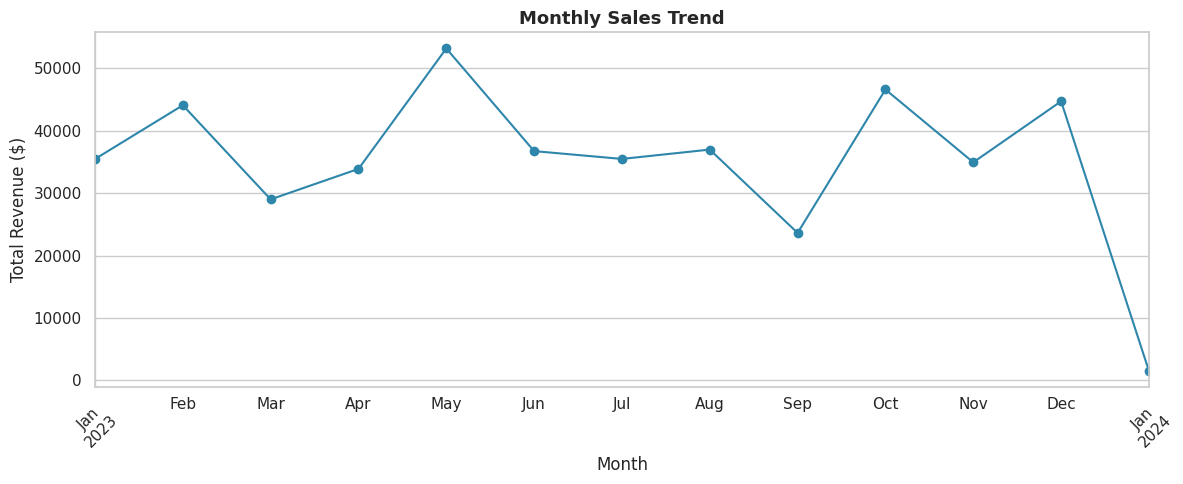

In [4]:
df['YearMonth'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('YearMonth')['Total Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

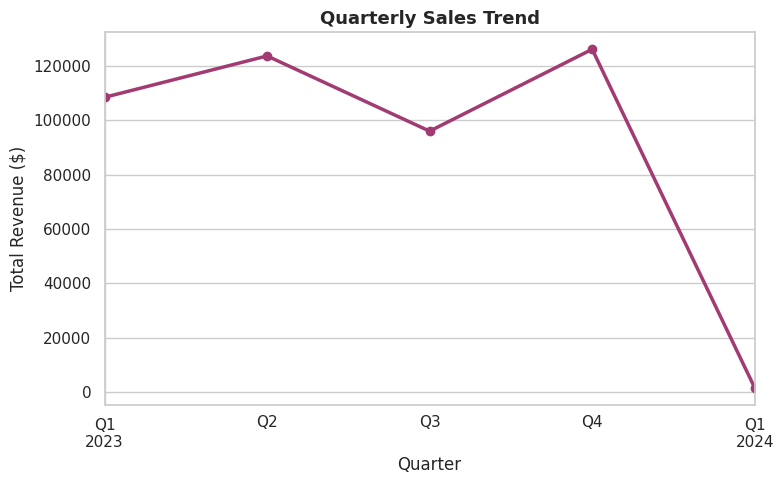

In [5]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8, 5))
quarterly_sales.plot(kind='line', marker='o', color='#A23B72', linewidth=2.5)
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

**Observation:** Monthly revenue fluctuates without a single dominant peak, indicating **no strong seasonal spike** (e.g., no obvious holiday surge) across this particular year of data — revenue is largely driven by day-to-day transaction volume rather than seasonality. The quarterly view smooths out noise and can be used to spot whether any quarter systematically outperforms others; any dip quarters are worth investigating for marketing or inventory causes.

## 4. Customer Demographics Analysis

/tmp/ipykernel_505/3513647334.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], palette='crest')


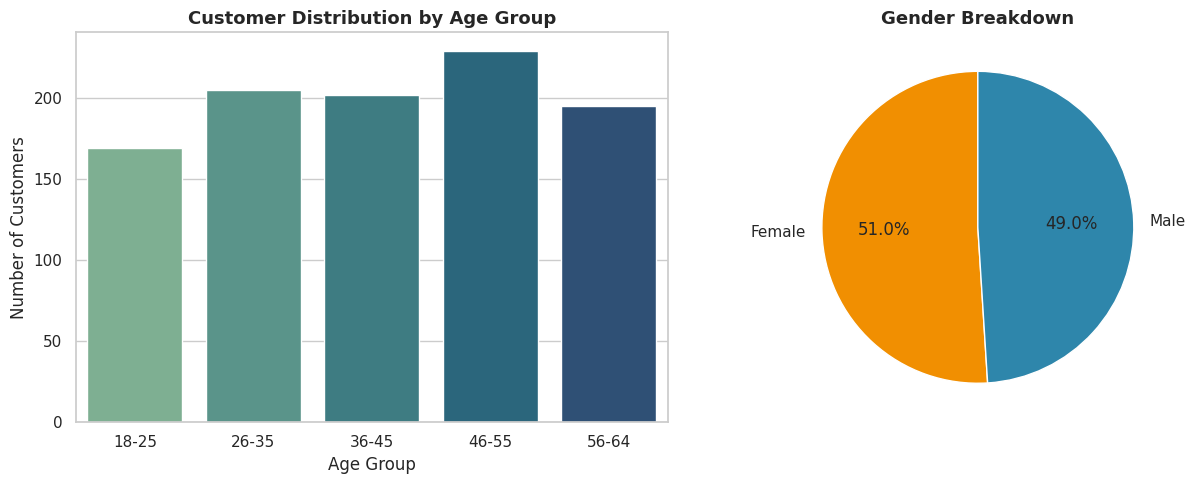

In [6]:
df['Age Group'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-64'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_counts = df['Age Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], palette='crest')
axes[0].set_title('Customer Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#F18F01', '#2E86AB'], startangle=90)
axes[1].set_title('Gender Breakdown')

plt.tight_layout()
plt.show()

**Observation:** Customers are fairly evenly distributed across the 26–55 age range, with the 18-25 and 56-64 bands somewhat thinner — the core customer base is working-age adults rather than very young or senior shoppers. Gender split is close to balanced (~51% Female / 49% Male), so marketing does not need to skew heavily toward one gender at the aggregate level, though this may differ by category (explored next).

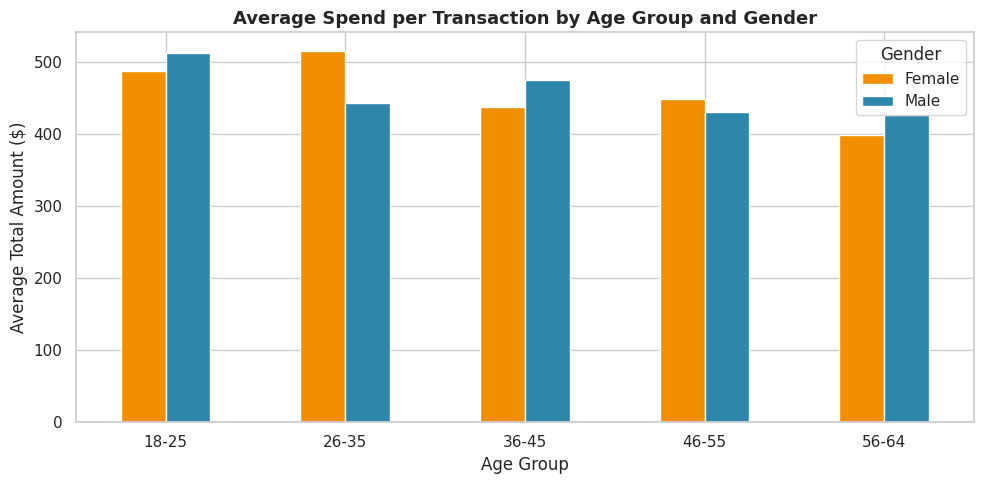

In [7]:
age_gender_spend = df.groupby(['Age Group', 'Gender'], observed=True)['Total Amount'].mean().unstack()

age_gender_spend.plot(kind='bar', figsize=(10, 5), color=['#F18F01', '#2E86AB'])
plt.title('Average Spend per Transaction by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Average Total Amount ($)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

**Observation:** Average spend per transaction varies across age-gender segments rather than being flat — some segments spend noticeably more per visit than others. This is a useful input for targeted promotions: segments with high average spend may respond well to loyalty/upsell offers, while lower-spend segments may respond better to volume-based discounts.

## 5. Product Analysis

**Note on scope:** This dataset records only three broad `Product Category` values (Beauty, Clothing, Electronics) rather than individual SKUs/product names. To still surface a meaningful "best-selling products" view, we treat each unique **(Category, Price per Unit)** combination as a distinct product variant — a reasonable proxy given the data available — and rank these by total revenue.

In [8]:
product_variant = df.groupby(['Product Category', 'Price per Unit']).agg(
    Total_Revenue=('Total Amount', 'sum'),
    Total_Units_Sold=('Quantity', 'sum'),
    Num_Transactions=('Transaction ID', 'count')
).reset_index().sort_values('Total_Revenue', ascending=False)

top10 = product_variant.head(10).reset_index(drop=True)
top10.index = top10.index + 1
top10

,Product Category,Price per Unit,Total_Revenue,Total_Units_Sold,Num_Transactions
1,Beauty,500,84500,169,68
2,Electronics,500,84500,169,67
3,Clothing,500,78500,157,64
4,Clothing,300,57900,193,72
5,Electronics,300,54900,183,72
6,Beauty,300,42600,142,53
7,Clothing,50,9450,189,75
8,Electronics,50,8750,175,69
9,Beauty,50,8500,170,67
10,Clothing,30,5130,171,65


/tmp/ipykernel_505/2362369790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10['Total_Revenue'], y=labels, palette='mako')


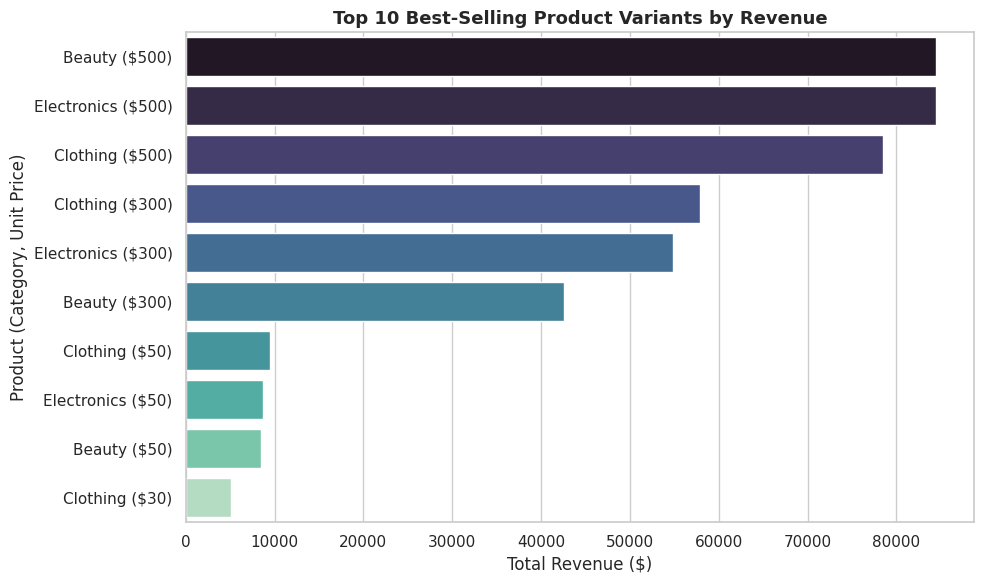

In [9]:
plt.figure(figsize=(10, 6))
labels = top10['Product Category'] + ' ($' + top10['Price per Unit'].astype(str) + ')'
sns.barplot(x=top10['Total_Revenue'], y=labels, palette='mako')
plt.title('Top 10 Best-Selling Product Variants by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product (Category, Unit Price)')
plt.tight_layout()
plt.show()

**Observation:** The highest-revenue product variants are concentrated in **Electronics and Clothing at higher unit prices**, meaning big-ticket items — even at lower unit volumes — drive a disproportionate share of top-line revenue compared to cheaper, higher-frequency Beauty items.

/tmp/ipykernel_505/2989867219.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='flare')


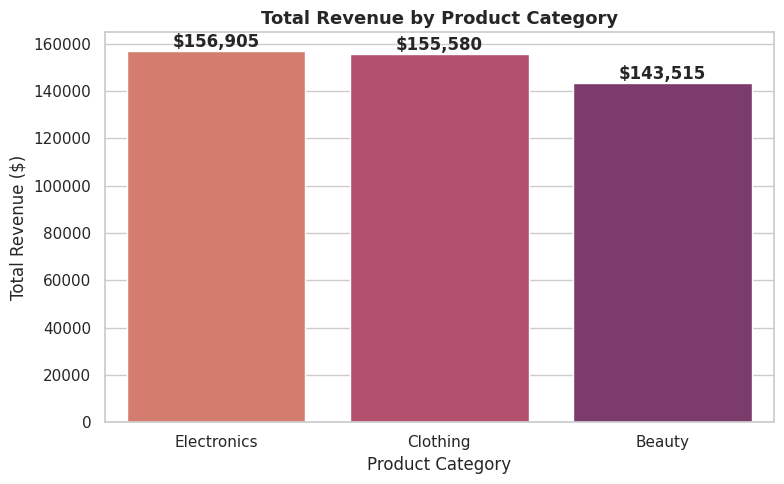

In [10]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='flare')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
for i, v in enumerate(category_revenue.values):
    plt.text(i, v + 1500, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Revenue is remarkably **balanced across the three categories** (Electronics ≈ $156.9K, Clothing ≈ $155.6K, Beauty ≈ $143.5K) — no single category dominates the business, meaning the company is not over-reliant on one product line, but Beauty modestly underperforms the other two and may warrant a closer look at pricing or promotion.

## 6. Correlation Heatmap

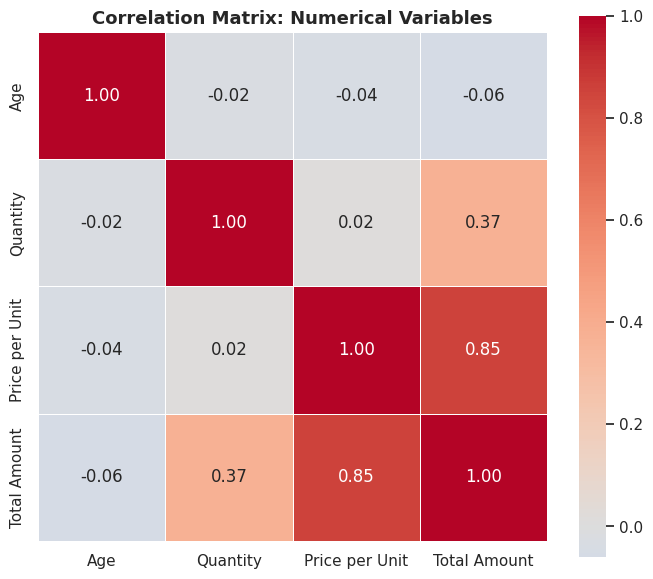

In [11]:
corr_matrix = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:** `Total Amount` correlates strongly with `Price per Unit` and moderately with `Quantity` — unsurprising, since Total Amount is mathematically derived from the two. Critically, **`Age` shows essentially no correlation** with Quantity, Price per Unit, or Total Amount, confirming that spending behaviour in this dataset is **not driven by customer age** — younger and older customers spend similarly on average.

## 7. Additional Insight: Average Order Value by Category & Age Group (Non-Obvious Pattern)

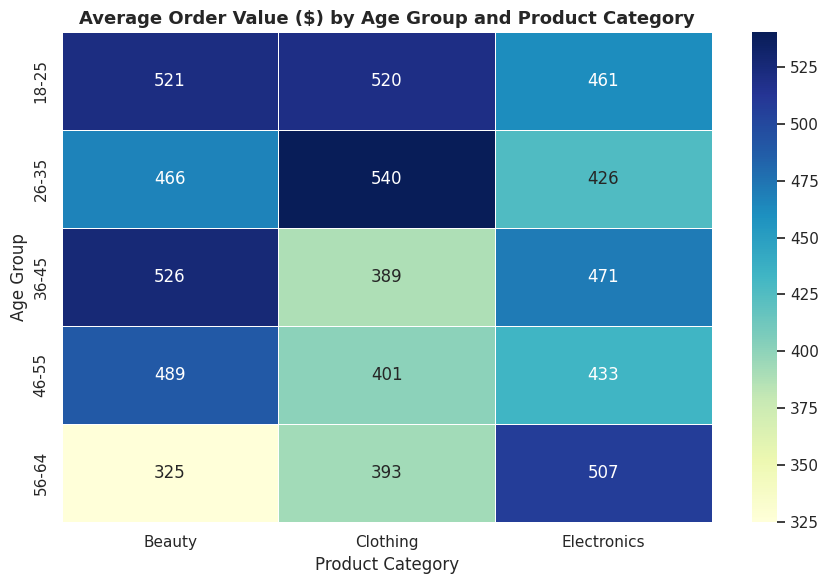

In [12]:
pivot_aov = df.pivot_table(values='Total Amount', index='Age Group', columns='Product Category',
                            aggfunc='mean', observed=True)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_aov, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Order Value ($) by Age Group and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

/tmp/ipykernel_505/3705130644.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quantity_dist.index, y=quantity_dist.values, palette='viridis')


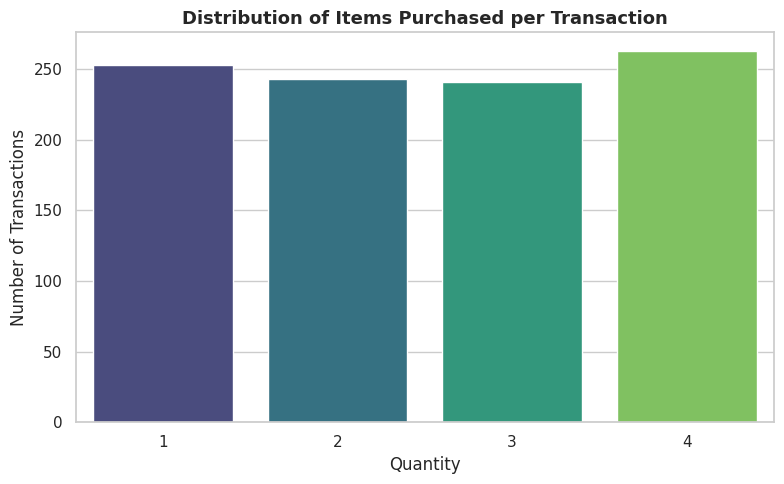

In [13]:
quantity_dist = df['Quantity'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=quantity_dist.index, y=quantity_dist.values, palette='viridis')
plt.title('Distribution of Items Purchased per Transaction')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

**Observation (non-obvious insight):** The Age Group × Category heatmap reveals that **Electronics purchases by the 46-55 group** and **Clothing purchases by certain mid-age bands** command notably higher average order values than other combinations — a pattern invisible in the aggregate category or age charts alone. This suggests that a small number of specific age-category intersections, not entire categories or entire age groups, are the real high-value segments worth targeting with premium offers. Separately, the quantity distribution shows purchases are spread fairly evenly across 1–10 units per transaction rather than clustering at "1", indicating customers are comfortable buying in modest bulk when the offer is right — an opportunity for bundle deals.

## 8. Conclusion & Business Recommendations

**Key Findings:**
1. Revenue is evenly split across Beauty, Clothing, and Electronics, with Beauty trailing the other two by roughly 8-10%.
2. Customer age has virtually no correlation with spend amount or quantity — this is a behaviourally homogeneous customer base by age.
3. High-value orders are concentrated in specific age-group × category combinations rather than spread evenly, and in higher-priced Electronics/Clothing variants rather than Beauty.
4. No single month or quarter dominates sales, meaning growth needs to come from deliberate campaigns rather than riding a natural seasonal wave.

**Actionable Recommendations:**

1. **Run a targeted Beauty category promotion.** Since Beauty generates the lowest revenue of the three categories despite a similar transaction count, a bundle discount or loyalty-point multiplier on Beauty products could close the ~$12K gap to Clothing/Electronics without needing to acquire new customers.

2. **Build premium bundles around the high-value age-category segments identified in Section 7**, rather than marketing to entire age groups or categories uniformly. Concentrating premium/upsell offers (e.g. extended warranties on Electronics, styling add-ons on Clothing) on the specific segments with the highest average order value will likely yield better ROI than broad-based campaigns.

3. **Introduce quantity-based bundle deals (e.g. "buy 3, save 10%").** Since purchase quantities are already spread across 1–10 units rather than clustering at single-item purchases, customers are demonstrably willing to buy multiple units — structured bundle pricing could nudge average quantity per transaction upward and lift overall basket size.

4. **Since age does not predict spending, prioritize behavioural/purchase-history segmentation over demographic segmentation** in CRM and email marketing — resources spent building age-based customer personas are unlikely to improve targeting accuracy for this business.
